# ⚔️ LangChain vs LangGraph — Same Task, Two Frameworks

**Video:** *LangChain vs LangGraph — When to Use What* | **Channel:** Prashant Nair (@prashantnairofficial)

---

### What This Notebook Demonstrates:
We build the **exact same customer support assistant** using both frameworks, then push it with a tricky scenario to see where LangChain stops and LangGraph takes over.

| | LangChain | LangGraph |
|---|---|---|
| **Architecture** | Linear chain | Conditional graph |
| **Control flow** | Sequential | Branches + loops |
| **State** | Passed through chain | Shared state object |
| **Best for** | Simple, linear workflows | Agentic, decision-heavy workflows |

**Key insight:** LangChain is the bricks. LangGraph is the architect.

---

**Tech Stack:** LangChain, LangGraph, OpenAI (gpt-4o-mini)  
**Author:** Prashant Nair | AI & GenAI Practitioner | Principal Trainer

## 📦 Step 1: Install Dependencies

In [ ]:
!pip install --quiet langchain==0.3.25 langchain-core==0.3.62 langchain-openai==0.3.18 langgraph==0.3.34 grandalf


## 🔐 Step 2: Configure OpenAI

In [ ]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
print("✅ OpenAI API key configured")

✅ OpenAI API key configured


## 🏪 Step 3: Shared Product Database

Both versions use the same simulated e-commerce database. This keeps the comparison fair.

In [ ]:
# ── Simulated E-Commerce Database ──
PRODUCTS = {
    "wireless-headphones": {
        "name": "ProSound Wireless Headphones",
        "price": 4999,
        "in_stock": False,  # ← Deliberately out of stock for the demo
        "category": "audio",
        "rating": 4.5,
        "description": "Premium noise-cancelling wireless headphones with 30hr battery."
    },
    "bluetooth-speaker": {
        "name": "BassBox Bluetooth Speaker",
        "price": 3499,
        "in_stock": True,
        "category": "audio",
        "rating": 4.3,
        "description": "Portable waterproof speaker with deep bass and 12hr battery."
    },
    "earbuds-pro": {
        "name": "SoundPods Pro Earbuds",
        "price": 3999,
        "in_stock": True,
        "category": "audio",
        "rating": 4.6,
        "description": "True wireless earbuds with ANC, transparency mode, and 24hr case battery."
    },
    "usb-microphone": {
        "name": "ClearVoice USB Microphone",
        "price": 2999,
        "in_stock": True,
        "category": "audio",
        "rating": 4.7,
        "description": "Studio-quality USB condenser mic for podcasting and streaming."
    },
}

ORDERS = {
    "ORD-12345": {"product": "wireless-headphones", "status": "shipped", "delivery": "March 28, 2026", "customer": "Rahul"},
    "ORD-67890": {"product": "bluetooth-speaker", "status": "processing", "delivery": "April 2, 2026", "customer": "Priya"},
}

print(f"✅ Product catalog: {len(PRODUCTS)} products")
print(f"✅ Order database: {len(ORDERS)} orders")
for pid, prod in PRODUCTS.items():
    stock = "✅ In Stock" if prod["in_stock"] else "❌ Out of Stock"
    print(f"   {prod['name']} — Rs.{prod['price']} — {stock}")

✅ Product catalog: 4 products
✅ Order database: 2 orders
   ProSound Wireless Headphones — Rs.4999 — ❌ Out of Stock
   BassBox Bluetooth Speaker — Rs.3499 — ✅ In Stock
   SoundPods Pro Earbuds — Rs.3999 — ✅ In Stock
   ClearVoice USB Microphone — Rs.2999 — ✅ In Stock


---

# 🔗 PART A: The LangChain Version

A simple, linear chain: **Question → Tool Selection → Tool Call → Answer**

This is the standard pattern for straightforward Q&A with tools.

In [ ]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

# ── Define Tools ──
@tool
def search_product(query: str) -> str:
    """Search for a product by name or category. Returns product details."""
    query_lower = query.lower()
    for pid, prod in PRODUCTS.items():
        if query_lower in prod["name"].lower() or query_lower in pid or query_lower in prod["category"]:
            stock = "In Stock" if prod["in_stock"] else "OUT OF STOCK"
            return f"{prod['name']} | Rs.{prod['price']} | {stock} | Rating: {prod['rating']}⭐ | {prod['description']}"
    return f"No product found matching '{query}'"

@tool
def check_order(order_id: str) -> str:
    """Check the status of an order by order ID."""
    order = ORDERS.get(order_id.upper())
    if order:
        return f"Order {order_id}: {PRODUCTS[order['product']]['name']} | Status: {order['status']} | Delivery: {order['delivery']}"
    return f"Order {order_id} not found."

# ── Build LangChain Agent ──
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)
lc_tools = [search_product, check_order]
llm_with_tools = llm.bind_tools(lc_tools)

print("✅ LangChain agent ready")
print(f"   Tools: {[t.name for t in lc_tools]}")
print("   Pattern: LLM with bound tools (single-pass)")

✅ LangChain agent ready
   Tools: ['search_product', 'check_order']
   Pattern: LLM with bound tools (single-pass)


In [ ]:
import json

def ask_langchain(question):
    """Ask the LangChain version."""
    print(f"\n{'═' * 60}")
    print(f"🔗 LANGCHAIN | Question: {question}")
    print(f"{'═' * 60}")

    messages = [
        SystemMessage(content="You are a helpful e-commerce customer support assistant. Use tools to look up product and order information. Be concise and helpful."),
        HumanMessage(content=question)
    ]

    response = llm_with_tools.invoke(messages)

    # Check if tools were called
    if response.tool_calls:
        for tc in response.tool_calls:
            print(f"   🔧 Tool called: {tc['name']}({tc['args']})")
            # Execute the tool
            tool_fn = {t.name: t for t in lc_tools}[tc["name"]]
            tool_result = tool_fn.invoke(tc["args"])
            print(f"   📋 Result: {tool_result}")
            # Get final answer with tool result
            messages.append(response)
            from langchain_core.messages import ToolMessage
            messages.append(ToolMessage(content=tool_result, tool_call_id=tc["id"]))
        final = llm_with_tools.invoke(messages)
        print(f"\n   🤖 Answer: {final.content}")
    else:
        print(f"\n   🤖 Answer: {response.content}")

    return response

In [35]:
# ── Test 1: Simple product query (LangChain handles this well) ──
ask_langchain("What's the price of the wireless headphones?");


════════════════════════════════════════════════════════════
🔗 LANGCHAIN | Question: What's the price of the wireless headphones?
════════════════════════════════════════════════════════════
   🔧 Tool called: search_product({'query': 'wireless headphones'})
   📋 Result: ProSound Wireless Headphones | Rs.4999 | OUT OF STOCK | Rating: 4.5⭐ | Premium noise-cancelling wireless headphones with 30hr battery.

   🤖 Answer: The ProSound Wireless Headphones are priced at Rs. 4999. However, they are currently out of stock. They have a rating of 4.5 stars and feature premium noise-cancelling with a 30-hour battery life.


In [36]:
# ── Test 2: Order status (LangChain handles this well) ──
ask_langchain("Where's my order ORD-12345?");


════════════════════════════════════════════════════════════
🔗 LANGCHAIN | Question: Where's my order ORD-12345?
════════════════════════════════════════════════════════════
   🔧 Tool called: check_order({'order_id': 'ORD-12345'})
   📋 Result: Order ORD-12345: ProSound Wireless Headphones | Status: shipped | Delivery: March 28, 2026

   🤖 Answer: Your order ORD-12345 for the ProSound Wireless Headphones has been shipped and is scheduled for delivery on March 28, 2026.


In [37]:
# ── Test 3: THE TRICKY ONE — Out of stock + needs alternatives ──
# LangChain will answer but CAN'T autonomously search for alternatives
ask_langchain("I want to buy the wireless \
headphones but they seem to be out of stock. \
  Can you find me a similar alternative?");


════════════════════════════════════════════════════════════
🔗 LANGCHAIN | Question: I want to buy the wireless headphones but they seem to be out of stock.   Can you find me a similar alternative?
════════════════════════════════════════════════════════════
   🔧 Tool called: search_product({'query': 'wireless headphones'})
   📋 Result: ProSound Wireless Headphones | Rs.4999 | OUT OF STOCK | Rating: 4.5⭐ | Premium noise-cancelling wireless headphones with 30hr battery.

   🤖 Answer: 


### 🔗 LangChain Result:

Notice what happened with the tricky question:
- LangChain called ONE tool (product search)
- It confirmed the headphones are out of stock
- But it **didn't autonomously search for alternatives** in the audio category
- It may suggest alternatives from its training data (not from OUR catalog)
- There's no loop-back mechanism to try again with a different search

**This is the ceiling.** LangChain executed a single pass — tool call → answer. It can't loop, branch, or make multi-step decisions.

---

# 🔄 PART B: The LangGraph Version

A conditional graph: **Understand → Route → Act → Check → Maybe Loop → Respond**

This version can make decisions, search for alternatives, and handle escalation.

In [38]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Literal, Annotated
import operator

# ── Define State ──
class SupportState(TypedDict):
    question: str
    intent: str  # product_query, order_status, out_of_stock, escalate
    product_info: str
    alternatives: list[str]
    order_info: str
    response: str
    needs_escalation: bool

print("✅ State schema defined")
print("   Fields: question, intent, product_info, alternatives, order_info, response, needs_escalation")

✅ State schema defined
   Fields: question, intent, product_info, alternatives, order_info, response, needs_escalation


In [39]:
# ── Define Node Functions ──

llm_graph = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)

def classify_intent(state: SupportState) -> SupportState:
    """Node 1: Understand what the customer wants."""
    question = state["question"]
    response = llm_graph.invoke([
        SystemMessage(content="""Classify the customer intent into exactly one of:
        - product_query: asking about a product's details, price, features
        - order_status: asking about an order's delivery or status
        - out_of_stock: asking about a product that might be unavailable, wants alternatives
        - escalate: angry, frustrated, wants human agent
        Reply with ONLY the intent label, nothing else."""),
        HumanMessage(content=question)
    ])
    intent = response.content.strip().lower()
    print(f"   🧠 Intent classified: {intent}")
    return {**state, "intent": intent}


def handle_product_query(state: SupportState) -> SupportState:
    """Node 2a: Look up product information."""
    result = search_product.invoke({"query": state["question"]})
    print(f"   🔧 Product search: {result[:80]}...")

    # Check if out of stock — if so, redirect
    if "OUT OF STOCK" in result:
        print(f"   ⚠️  Product is OUT OF STOCK → routing to alternatives")
        return {**state, "product_info": result, "intent": "out_of_stock"}

    return {**state, "product_info": result}


def handle_order_status(state: SupportState) -> SupportState:
    """Node 2b: Check order status."""
    # Extract order ID from question
    import re
    match = re.search(r'ORD-\d+', state["question"].upper())
    if match:
        result = check_order.invoke({"order_id": match.group()})
    else:
        result = "Could not find an order ID in your question. Please provide your order ID (e.g., ORD-12345)."
    print(f"   📦 Order lookup: {result}")
    return {**state, "order_info": result}


def find_alternatives(state: SupportState) -> SupportState:
    """Node 3: Search for alternative products in the same category. THIS IS THE LOOP."""
    print(f"   🔄 Searching for alternatives...")

    # Find the category of the original product
    original_category = None
    for pid, prod in PRODUCTS.items():
        if prod["name"].lower() in state["question"].lower() or pid in state["question"].lower():
            original_category = prod["category"]
            break

    if not original_category:
        original_category = "audio"  # default for demo

    # Find in-stock alternatives in the same category
    alts = []
    for pid, prod in PRODUCTS.items():
        if prod["category"] == original_category and prod["in_stock"]:
            alts.append(f"{prod['name']} — Rs.{prod['price']} — {prod['rating']}⭐ — {prod['description']}")
            print(f"   ✅ Found: {prod['name']} (Rs.{prod['price']})")

    if not alts:
        alts = ["No alternatives found in this category."]

    return {**state, "alternatives": alts}


def handle_escalation(state: SupportState) -> SupportState:
    """Node 4: Escalate to human support."""
    print(f"   🚨 ESCALATING to human agent")
    return {**state, "needs_escalation": True, "response": "I understand your frustration. Let me connect you with a human support agent who can help resolve this. Your case has been marked as priority. A support agent will reach out within 15 minutes."}


def generate_response(state: SupportState) -> SupportState:
    """Node 5: Generate the final response using all gathered context."""
    context_parts = []
    if state.get("product_info"):
        context_parts.append(f"Product info: {state['product_info']}")
    if state.get("alternatives"):
        context_parts.append(f"Available alternatives: {'; '.join(state['alternatives'])}")
    if state.get("order_info"):
        context_parts.append(f"Order info: {state['order_info']}")

    context = "\n".join(context_parts)

    response = llm_graph.invoke([
        SystemMessage(content=f"""You are a helpful e-commerce customer support assistant.
Use the following information to answer the customer's question helpfully and concisely.
If suggesting alternatives, compare them and recommend the best option.

Context:
{context}"""),
        HumanMessage(content=state["question"])
    ])

    print(f"   ✍️  Response generated")
    return {**state, "response": response.content}

print("✅ All node functions defined")

✅ All node functions defined


In [40]:
# ── Build the Graph ──

def route_by_intent(state: SupportState) -> str:
    """Conditional edge: route based on classified intent."""
    intent = state.get("intent", "product_query")
    if "order" in intent:
        return "handle_order"
    elif "escalat" in intent:
        return "escalate"
    elif "out_of_stock" in intent or "alternative" in intent:
        return "find_alternatives"
    else:
        return "handle_product"

def route_after_product(state: SupportState) -> str:
    """After product lookup, check if we need alternatives."""
    if state.get("intent") == "out_of_stock":
        return "find_alternatives"
    return "generate_response"

# Build the graph
workflow = StateGraph(SupportState)

# Add nodes
workflow.add_node("classify", classify_intent)
workflow.add_node("handle_product", handle_product_query)
workflow.add_node("handle_order", handle_order_status)
workflow.add_node("find_alternatives", find_alternatives)
workflow.add_node("escalate", handle_escalation)
workflow.add_node("generate_response", generate_response)

# Set entry point
workflow.set_entry_point("classify")

# Add conditional edges
workflow.add_conditional_edges(
    "classify",
    route_by_intent,
    {
        "handle_product": "handle_product",
        "handle_order": "handle_order",
        "find_alternatives": "find_alternatives",
        "escalate": "escalate",
    }
)

# After product query, might need alternatives
workflow.add_conditional_edges(
    "handle_product",
    route_after_product,
    {
        "find_alternatives": "find_alternatives",
        "generate_response": "generate_response",
    }
)

# Linear edges
workflow.add_edge("handle_order", "generate_response")
workflow.add_edge("find_alternatives", "generate_response")
workflow.add_edge("generate_response", END)
workflow.add_edge("escalate", END)

# Compile
graph = workflow.compile()

print("✅ LangGraph agent compiled!")
print("   Nodes: classify → handle_product / handle_order / find_alternatives / escalate → generate_response")
print("   Conditional routing based on intent + stock status")

✅ LangGraph agent compiled!
   Nodes: classify → handle_product / handle_order / find_alternatives / escalate → generate_response
   Conditional routing based on intent + stock status


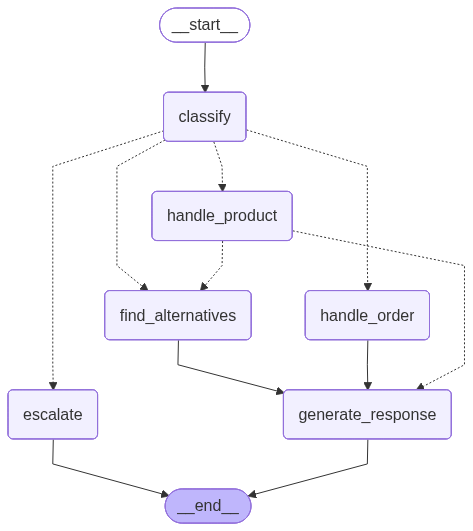

In [ ]:
graph

In [ ]:
def ask_langgraph(question):
    """Ask the LangGraph version."""
    print(f"\n{'═' * 60}")
    print(f"🔄 LANGGRAPH | Question: {question}")
    print(f"{'═' * 60}")

    initial_state = {
        "question": question,
        "intent": "",
        "product_info": "",
        "alternatives": [],
        "order_info": "",
        "response": "",
        "needs_escalation": False,
    }

    result = graph.invoke(initial_state)

    print(f"\n{'─' * 60}")
    print(f"🤖 FINAL RESPONSE:")
    print(f"{result['response']}")

    if result.get("needs_escalation"):
        print(f"\n🚨 Case escalated to human support.")

    return result

In [41]:
# ── Test 1: Simple product query (both handle this well) ──
ask_langgraph("What's the price of the wireless headphones?");


════════════════════════════════════════════════════════════
🔄 LANGGRAPH | Question: What's the price of the wireless headphones?
════════════════════════════════════════════════════════════
   🧠 Intent classified: product_query
   🔧 Product search: No product found matching 'What's the price of the wireless headphones?'...
   ✍️  Response generated

────────────────────────────────────────────────────────────
🤖 FINAL RESPONSE:
I'm sorry, but it seems that there are no wireless headphones currently available in our inventory. If you're looking for alternatives, I can help you find similar products or suggest other types of headphones. Would you like me to do that?


In [42]:
# ── Test 2: Order status (both handle this well) ──
ask_langgraph("Where's my order ORD-12345?");


════════════════════════════════════════════════════════════
🔄 LANGGRAPH | Question: Where's my order ORD-12345?
════════════════════════════════════════════════════════════
   🧠 Intent classified: order_status
   📦 Order lookup: Order ORD-12345: ProSound Wireless Headphones | Status: shipped | Delivery: March 28, 2026
   ✍️  Response generated

────────────────────────────────────────────────────────────
🤖 FINAL RESPONSE:
Your order, ORD-12345 for the ProSound Wireless Headphones, has been shipped and is scheduled to be delivered on March 28, 2026. If you have any further questions or need assistance, feel free to ask!


In [43]:
# ── Test 3: THE TRICKY ONE — Out of stock + needs alternatives ──
# THIS is where LangGraph shines
ask_langgraph("I want to buy the wireless \
 headphones but they seem to be out of  \
 stock. Can you find me a similar \
 alternative?");


════════════════════════════════════════════════════════════
🔄 LANGGRAPH | Question: I want to buy the wireless  headphones but they seem to be out of   stock. Can you find me a similar  alternative?
════════════════════════════════════════════════════════════
   🧠 Intent classified: out_of_stock
   🔄 Searching for alternatives...
   ✅ Found: BassBox Bluetooth Speaker (Rs.3499)
   ✅ Found: SoundPods Pro Earbuds (Rs.3999)
   ✅ Found: ClearVoice USB Microphone (Rs.2999)
   ✍️  Response generated

────────────────────────────────────────────────────────────
🤖 FINAL RESPONSE:
I recommend the SoundPods Pro Earbuds as a great alternative to wireless headphones. They are true wireless earbuds with active noise cancellation (ANC) and a transparency mode, allowing you to enjoy your music while still being aware of your surroundings. They also come with a 24-hour battery life when using the charging case, making them very convenient for extended use. 

The SoundPods Pro are priced at Rs. 3999 a

In [44]:
# ── Test 4: Escalation (angry customer) ──
ask_langgraph("This is ridiculous! I've been waiting 2 weeks for my order and nobody is helping me. I want to speak to a manager NOW!");


════════════════════════════════════════════════════════════
🔄 LANGGRAPH | Question: This is ridiculous! I've been waiting 2 weeks for my order and nobody is helping me. I want to speak to a manager NOW!
════════════════════════════════════════════════════════════
   🧠 Intent classified: escalate
   🚨 ESCALATING to human agent

────────────────────────────────────────────────────────────
🤖 FINAL RESPONSE:
I understand your frustration. Let me connect you with a human support agent who can help resolve this. Your case has been marked as priority. A support agent will reach out within 15 minutes.

🚨 Case escalated to human support.


---

## ⚔️ Head-to-Head Comparison

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         LANGCHAIN vs LANGGRAPH — COMPARISON                ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  FEATURE          │ LANGCHAIN      │ LANGGRAPH             ║
║  ─────────────────┼────────────────┼────────────────────── ║
║  Control Flow     │ Sequential     │ Conditional + Loops   ║
║  State Mgmt       │ Pass-through   │ Shared state object   ║
║  Looping          │ ❌ No          │ ✅ Yes                ║
║  Branching        │ ❌ No          │ ✅ Conditional edges  ║
║  Human-in-Loop    │ ❌ Manual      │ ✅ Built-in           ║
║  Visualization    │ ❌ No          │ ✅ Graph rendering    ║
║  Complexity       │ Low            │ Medium-High           ║
║  Best For         │ Linear tasks   │ Agentic workflows     ║
║                                                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  🔑 KEY INSIGHT:                                           ║
║  "LangChain is the bricks. LangGraph is the architect."    ║
║                                                            ║
║  They're LAYERS, not alternatives.                         ║
║  LangGraph uses LangChain components inside it.            ║
║                                                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  📐 DECISION FRAMEWORK:                                    ║
║                                                            ║
║  Linear workflow? → LangChain                              ║
║  Needs decisions/loops? → LangGraph                        ║
║  Building an agent? → LangGraph                            ║
║                                                            ║
║  Start simple. Graduate when you need to.                  ║
║                                                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  📺 SUBSCRIBE: @prashantnairofficial                       ║
║  Next: Agentic Design Patterns Deep Dive                   ║
║                                                            ║
╚══════════════════════════════════════════════════════════════╝
""")

---

## 🔜 What's Next?

| Video | Topic | Status |
|-------|-------|--------|
| #1 | What is Agentic AI? | ✅ Done |
| #2 | Build a RAG Pipeline from Scratch | ✅ Done |
| #3 | LangChain vs LangGraph (This video) | ✅ Done |
| #4 | Agentic Design Patterns Deep Dive | 🔜 Next |
| #5 | Advanced RAG: Corrective RAG & Agentic RAG | 📋 Planned |

**Subscribe:** [Prashant Nair on YouTube](https://youtube.com/@prashantnairofficial)

---

*Built by Prashant Nair | AI & GenAI Practitioner | Principal Trainer*  
*Tech: LangChain + LangGraph + OpenAI (gpt-4o-mini)*